In [4]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data_loader import load_data

In [6]:
data = load_data('data_2')

## EDA

In [7]:
data.isnull().mean()

log_id          0.0
worker_id       0.0
process_name    0.0
item_id         0.0
time_from       0.0
time_to         0.0
dtype: float64

In [8]:
processes = data.process_name.unique()
print(processes)

<StringArray>
['collection', 'transfer', 'placement']
Length: 3, dtype: str


In [9]:
items = data.item_id.unique()
print(items)

<StringArray>
['item_3', 'item_4', 'item_5', 'item_2', 'item_1']
Length: 5, dtype: str


In [10]:
workers = data.worker_id.unique()
print(workers)

<StringArray>
['worker_1', 'worker_2', 'worker_3', 'worker_4', 'worker_5']
Length: 5, dtype: str


Task duration is between 9.468 and 80.126 seconds


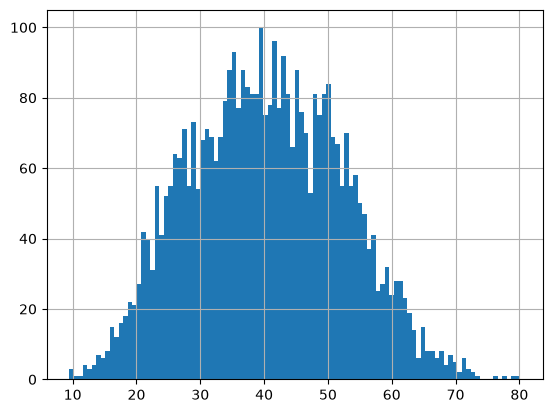

In [11]:
data['duration'] = (data.time_to - data.time_from).dt.total_seconds()
print(f'Task duration is between {data.duration.min()} and {data.duration.max()} seconds')

data.duration.hist(bins=100)
plt.show()

It looks like the data is pretty clean.

In [12]:
data.time_from.min(), data.time_to.max()

(Timestamp('2025-07-01 08:06:01'), Timestamp('2025-09-30 22:59:17.449000'))

In [13]:
data['date'] = pd.to_datetime(data.time_from.dt.date)
data.date.nunique()

90

In our date range there are more than 90 days. So let's find out what days are missing.

In [14]:
dates = pd.date_range(data.date.min(), data.date.max(), freq='D')

dates.difference(data.date)

DatetimeIndex(['2025-07-31', '2025-08-31'], dtype='datetime64[s]', freq=None)

So, it looks like no collection, placement, or transfer processes were carried out during the last days of July and August. However, on the last day of August, these processes were performed.

In [15]:
index_columns = ['date', 'worker_id', 'item_id', 'process_name']

df = data.groupby(index_columns, as_index=False).log_id.count()


full_index = pd.MultiIndex.from_product(
    [dates, workers, items, processes],
    names=index_columns
)

df = df.set_index(index_columns)\
    .reindex(full_index)\
    .reset_index()\
    .sort_values(by=['date', 'worker_id', 'item_id', 'process_name'])\
    .fillna(0)

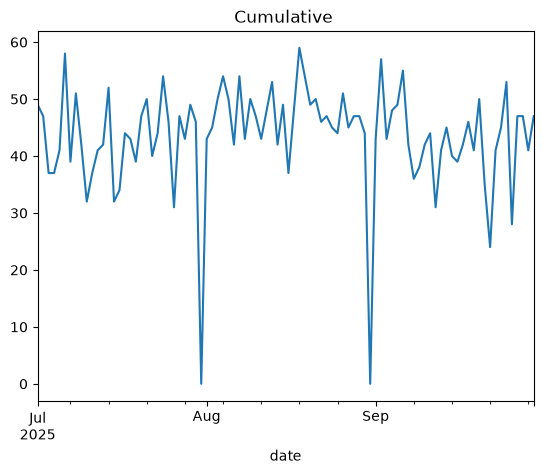

In [16]:
df.groupby('date').log_id.sum().plot()
plt.title('Cumulative ')
plt.show()

In [17]:
def plot_by_date(df, column):
    daily_logs = df.groupby(['date', column], as_index=False).log_id.sum()
    
    plot_df = daily_logs.pivot(
        index='date',
        columns=column,
        values='log_id'
    ).fillna(0)
    
    ax = plot_df.plot(figsize=(15, 6), marker="o")
    ax.set_title(f'Daily number of logs by {column}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Number of logs')
    plt.tight_layout()
    plt.show()


def heatmap_by_date(df, column):
    daily_logs = df.groupby(['date', column], as_index=False).log_id.sum()
    
    plot_df = daily_logs.pivot(
        index='date',
        columns=column,
        values='log_id'
    ).fillna(0)

    plt.figure(figsize=(16, 4))
    sns.heatmap(plot_df.T, cmap="Blues")
    plt.xlabel('Date')
    plt.ylabel(column)
    plt.show()

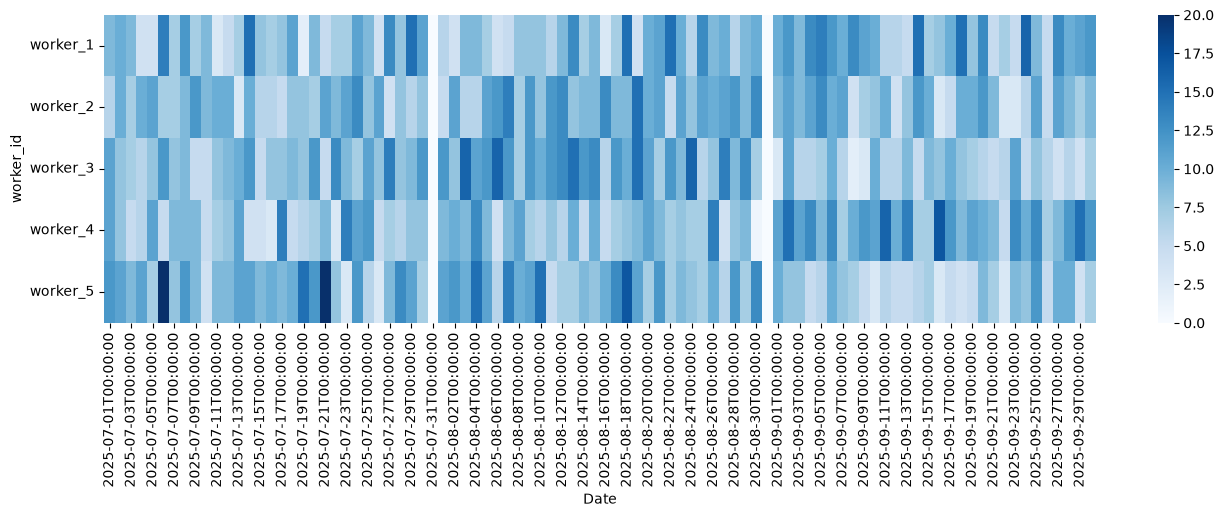

In [18]:
heatmap_by_date(df, 'worker_id')

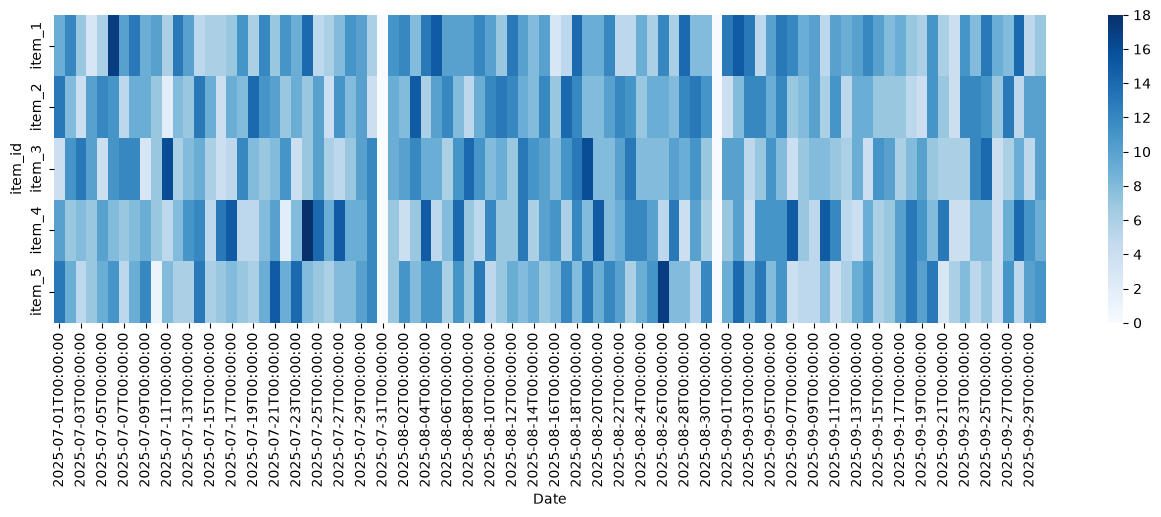

In [19]:
heatmap_by_date(df, 'item_id')

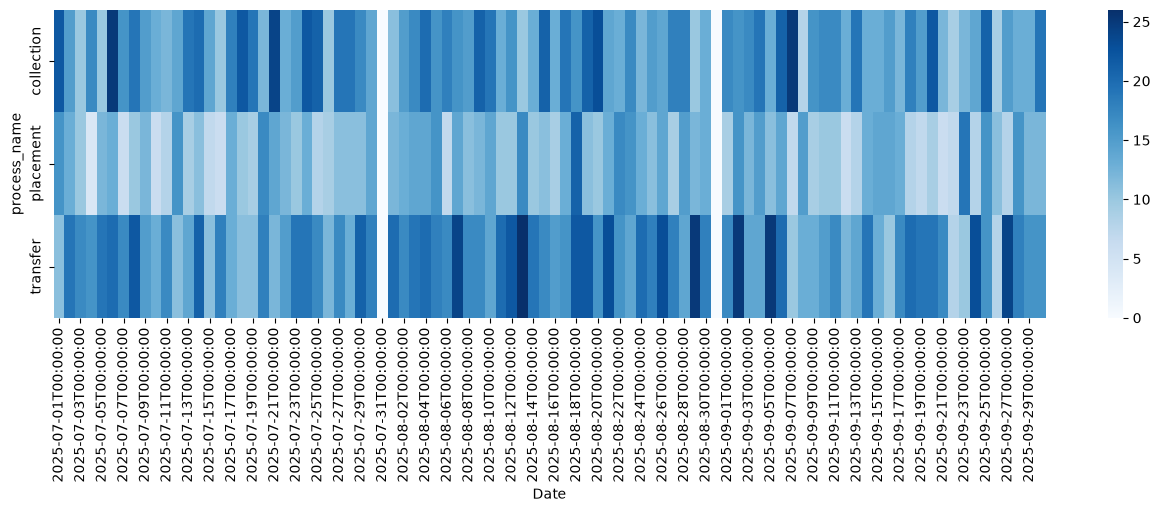

In [20]:
heatmap_by_date(df, 'process_name')

In [21]:
df.groupby(['date', 'worker_id']).log_id.sum().describe()

count    460.000000
mean       8.695652
std        3.416413
min        0.000000
25%        6.000000
50%        9.000000
75%       11.000000
max       20.000000
Name: log_id, dtype: float64

In [22]:
df.groupby(['date', 'item_id']).log_id.sum().describe()

count    460.000000
mean       8.695652
std        3.252414
min        0.000000
25%        7.000000
50%        9.000000
75%       11.000000
max       18.000000
Name: log_id, dtype: float64

In [23]:
df = data.groupby(['worker_id', 'item_id', 'process_name'], as_index=False)\
    .agg(
        min_duration=('duration', 'min'),
        avg_duration=('duration', 'mean'), 
        max_duration=('duration', 'max')
    )
df

,worker_id,item_id,process_name,min_duration,avg_duration,max_duration
0,worker_1,item_1,collection,14.917,26.556518,41.046
1,worker_1,item_1,placement,24.784,34.332788,53.011
2,worker_1,item_1,transfer,31.025,44.384175,61.139
3,worker_1,item_2,collection,15.989,27.794241,42.155
4,worker_1,item_2,placement,20.793,33.728600,44.894
...,...,...,...,...,...,...
65,worker_5,item_4,placement,37.385,48.527093,63.284
66,worker_5,item_4,transfer,49.790,60.487533,71.518
67,worker_5,item_5,collection,34.600,47.516358,65.573
68,worker_5,item_5,placement,45.110,52.598841,59.734


In [24]:
df.pivot(index=['worker_id', 'item_id'], columns='process_name', values=['min_duration', 'avg_duration',
       'max_duration'])

min_duration                    avg_duration             \
process_name        collection placement transfer   collection  placement   
worker_id item_id                                                           
worker_1  item_1        14.917    24.784   31.025    26.556518  34.332788   
          item_2        15.989    20.793   33.039    27.794241  33.728600   
          item_3        24.174    30.299   34.798    36.418589  42.280491   
          item_4        15.353    19.945   31.669    30.049655  33.762983   
          item_5        21.807    26.071   33.011    32.385188  38.549917   
worker_2  item_1        10.138       NaN   26.859    22.772431        NaN   
          item_2        10.011       NaN   27.377    21.530766        NaN   
          item_3        22.446       NaN   35.551    32.125312        NaN   
          item_4        11.305       NaN   27.311    23.464373        NaN   
          item_5        18.041       NaN   28.357    26.906738        NaN   
worker_3  item_1        16.712    22.779   36.485    24.888341  37.485895   
          item_2         9.468    24.610   36.256    24.854542  36.458517   
          item_3        25.979    39.318   48.091    35.307212  47.643435   
          item_4        12.156    24.910   36.508    24.898089  38.307327   
          item_5        17.670    29.053   42.608    29.059737  40.922022   
worker_4  item_1        21.297    14.461   39.382    31.770783  25.859790   
          item_2        20.458    17.905   35.915    32.634250  25.482731   
          item_3        34.186    23.675   46.002    41.046667  35.465912   
          item_4        22.208    14.068   36.087    34.998359  27.134154   
          item_5        25.175    14.258   37.688    38.187500  29.668186   
worker_5  item_1        28.070    36.315   45.116    41.353425  48.305542   
          item_2        32.067    30.161   48.501    41.665389  47.294766   
          item_3        40.560    43.016   54.210    51.091909  57.246818   
          item_4        31.390    37.385   49.790    43.803259  48.527093   
          item_5        34.600    45.110   48.594    47.516358  52.598841   

                             max_duration                     
process_name        transfer   collection placement transfer  
worker_id item_id                                             
worker_1  item_1   44.384175       41.046    53.011   61.139  
          item_2   42.965180       42.155    44.894   55.060  
          item_3   51.997475       52.514    56.881   66.944  
          item_4   45.068949       50.096    50.362   60.235  
          item_5   48.448627       50.122    52.292   69.855  
worker_2  item_1   37.128389       36.099       NaN   48.423  
          item_2   38.562814       32.511       NaN   49.557  
          item_3   47.822241       41.780       NaN   61.357  
          item_4   39.638138       38.101       NaN   54.357  
          item_5   42.526538       38.485       NaN   53.638  
worker_3  item_1   47.600431       38.318    50.280   63.301  
          item_2   46.906585       35.967    51.323   56.696  
          item_3   57.007469       45.170    57.796   70.854  
          item_4   49.067550       38.852    52.847   58.986  
          item_5   52.665949       41.713    54.688   63.766  
worker_4  item_1   47.181788       42.680    34.858   58.473  
          item_2   47.380662       45.172    35.114   58.709  
          item_3   56.695846       54.823    50.044   67.689  
          item_4   49.140055       44.700    35.043   63.578  
          item_5   51.743298       50.632    42.561   65.622  
worker_5  item_1   56.697242       53.886    59.317   71.548  
          item_2   56.650167       52.257    62.861   65.759  
          item_3   66.521145       59.124    70.942   80.126  
          item_4   60.487533       57.450    63.284   71.518  
          item_5   60.584213       65.573    59.734   72.190

In [25]:
data.groupby('worker_id')['duration'].describe()

,count,mean,std,min,25%,50%,75%,max
worker_id,,,,,,,,
worker_1,800.0,37.853984,10.179598,14.917,30.30700,37.1070,44.91550,69.855
worker_2,800.0,33.987012,9.915959,10.011,26.54300,34.7725,41.60300,61.357
worker_3,800.0,39.584321,11.353504,9.468,30.94725,39.8365,48.95275,70.854
worker_4,800.0,38.488980,11.023750,14.068,29.89825,37.0325,47.17950,67.689
worker_5,800.0,51.734813,9.002518,28.070,44.91650,51.6550,58.18125,80.126


In [26]:
data.groupby('item_id')['duration'].describe()

,count,mean,std,min,25%,50%,75%,max
item_id,,,,,,,,
item_1,831.0,37.614963,11.383246,10.138,28.60500,37.8820,45.6035,71.548
item_2,806.0,37.358403,11.277964,9.468,28.67675,37.4895,45.7190,65.759
item_3,779.0,46.585883,11.528376,22.446,36.84350,46.9230,54.8825,80.126
item_4,807.0,38.567275,11.522679,11.305,29.45400,38.5260,46.8960,71.518
item_5,777.0,41.874115,11.468444,14.258,32.90100,42.0670,50.5960,72.190


In [27]:
data.groupby('process_name')['duration'].describe()

,count,mean,std,min,25%,50%,75%,max
process_name,,,,,,,,
collection,1436.0,32.387797,9.561278,9.468,25.2745,31.8385,39.03625,65.573
placement,1038.0,39.063423,10.506928,14.068,30.9310,38.2140,46.90900,70.942
transfer,1526.0,48.664861,9.110779,26.859,41.9140,48.4605,54.69425,80.126
